**Training Autoencoder**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Stabilizing for Reproduciblity
torch.manual_seed(42)
np.random.seed(42)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

embeddings = np.load('embeddings.npy')
X = torch.tensor(embeddings, dtype=torch.float32).to(device)

dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, input_dim=384, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)   
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Linear(256, input_dim)
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z
    
    def encode(self, x):
        return self.encoder(x)


model = Autoencoder(input_dim=384, latent_dim=32).to(device)
print(model)
print(f"\nTotal paramters: {sum(p.numel() for p in model.parameters()):,}")

Using Device: cuda
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=384, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Linear(in_features=128, out_features=256, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Linear(in_features=25

Epoch   5 / 50 | Loss: 0.002134
Epoch  10 / 50 | Loss: 0.001837
Epoch  15 / 50 | Loss: 0.001769
Epoch  20 / 50 | Loss: 0.001714
Epoch  25 / 50 | Loss: 0.001649
Epoch  30 / 50 | Loss: 0.001623
Epoch  35 / 50 | Loss: 0.001570
Epoch  40 / 50 | Loss: 0.001531
Epoch  45 / 50 | Loss: 0.001482
Epoch  50 / 50 | Loss: 0.001451


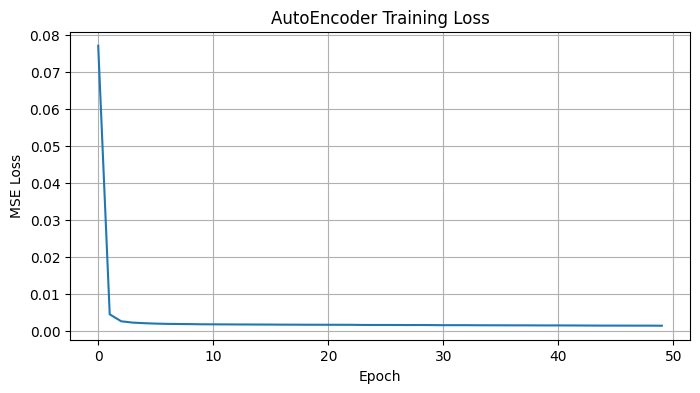

In [ ]:
# Training
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Scheduler is used to course correct
# If the model is stuck of 5 epochs i.e. loss hasent reduced, the adjustements are made smaller, learning rate is cut in half
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)
criterion = nn.MSELoss()

EPOCHS = 50
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for (batch,) in loader:
        optimizer.zero_grad()  
        recon, z = model(batch) # Model takes a batch, and produces a reconstruction
        loss = criterion(recon, batch) # using MSE to calculated difference between reconstructed batch and original batch 
        loss.backward() # finds out how much each individual weight out of 285,472 - contributed to the loss
        optimizer.step() # Adam optimizer nudges the weights in a direction to reduce loss
        epoch_loss += loss.item() 

    avg_loss = epoch_loss/len(loader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss) # if loss hasn't improved, the learning rate is cut in half

    if (epoch + 1) % 5 == 0 :
        print(f"Epoch {epoch+1:3d} / {EPOCHS} | Loss: {avg_loss:.6f}")

plt.figure(figsize=(8,4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AutoEncoder Training Loss')
plt.grid(True)
plt.savefig('autoencoder_loss.png', dpi=100)
plt.show()

# The low loss signals that the model is correctly able to compress
# the 384 dimensions into 32 dimensions while retaining the semantic meaning

In [ ]:
# Extracting latent vectors
# The raw embeddings (384 dimensions) contains sparse information
# Clustering 384 dimensions can get mathematically noisy
# The latent space is a dense representation, the model maps abstract concepts into mathematicas coordinates
# This filters away noise and simplifies geometry
# Physical proximity = semantic similarity  

model.eval()
with torch.no_grad():
    X_full = torch.tensor(embeddings, dtype=torch.float32).to(device)
    recon_full, Z = model(X_full)
    Z = Z.cpu().numpy()
    recon_full = recon_full.cpu().numpy()

print(f"Latent space shape: {Z.shape}")
# Expected: (7824, 32)

np.save('latent_vectors.npy', Z)

Latent space shape: (7824, 32)


In [ ]:
# Running k-means to verify autoencoder effectiveness
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler_emb = StandardScaler()
scaler_z = StandardScaler()

X_scaled = scaler_emb.fit_transform(embeddings)
Z_scaled = scaler_z.fit_transform(Z)

# Fixed k for comparison 
K = 10

print("Running KMeans on raw embeddings....")
km_raw = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_raw = km_raw.fit_predict(X_scaled)
sil_raw = silhouette_score(X_scaled, labels_raw, sample_size=2000)

print("Running Kmeans on latent vectors....")
km_latent = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_latent = km_latent.fit_predict(Z_scaled)
sil_latent = silhouette_score(Z_scaled, labels_latent, sample_size=2000)

print(f"\nSilhouette Score for Raw embeddings (384d): {sil_raw:.4f}")
print(f"\nSilhouette Score for Latent vectors (384d): {sil_latent:.4f}")

Running KMeans on raw embeddings....
Running Kmeans on latent vectors....

Silhouette Score for Raw embeddings (384d): 0.0256

Silhouette Score for Latent vectors (384d): 0.2121


- Latent ≥ Raw -> autoencoder works fine 
- Latent < Raw by a small margin (< 0.02) -> IDEC joint training compensates for minor changes
- Latent << Raw (> 0.05 gap) -> autoencoder needs more epochs/architecture adjustment


On running epochs > 50 (~140-200) the latent vector silhouette score reduced to ~0.0776, although the training loss flattened out at 140-150 epochs, This indicates that the autoencoder is memorizing the data.

Hence to prevent cluster bleeding the epochs will be set to 50 and silhouette score will be considered to better evaluate cluster separation

In [ ]:
# Reconstruction Sanity check
# Check how well the decoder reconstructs the original embeddings
import pandas as pd

data = pd.read_csv('reviews_preprocessed.csv')


recon_errors = np.mean((embeddings - recon_full) ** 2, axis=1)
print(f"Mean reconstruction error: {recon_errors.mean():.6f}")
print(f"Std reconstruction error:  {recon_errors.std():.6f}")
print(f"Max reconstruction error:  {recon_errors.max():.6f}") 

# Flagging outliers
outlier_threshold = recon_errors.mean() + 3 * recon_errors.std()
outliers = np.where(recon_errors > outlier_threshold)[0] 
print(f"\nHigh reconstruction error reviews: {len(outliers)}")
print("Sample outlier reviews:")
for idx in outliers[:3]:
    print(f"  [{idx}] {data['content_clean'].iloc[idx][:100]}")

Mean reconstruction error: 0.001453
Std reconstruction error:  0.000455
Max reconstruction error:  0.004500

High reconstruction error reviews: 73
Sample outlier reviews:
  [86] is it necessary to sign up account while making a new account it's shows error oops try again later
  [94] my backup is gone very important data deleted
  [132] google login not working at all tried 2 accounts gets stuck at setting up


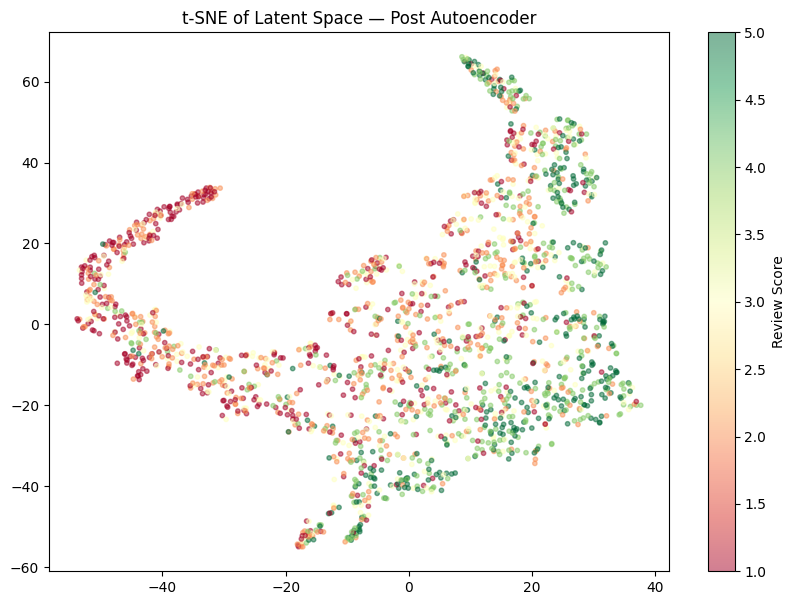

In [ ]:
# T-SNE on latent space

from sklearn.manifold import TSNE

sample_idx = np.random.choice(len(Z), 2000, replace=False)
Z_sample = Z[sample_idx]
scores_sample = data['score'].iloc[sample_idx].values

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z_sample)

plt.figure(figsize=(10,7))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=scores_sample, cmap='RdYlGn', alpha=0.5 , s=10)
plt.colorbar(scatter, label='Review Score')
plt.title('t-SNE of Latent Space — Post Autoencoder')
plt.savefig('tsne_phase3_latent.png', dpi=150)
plt.show()

In [ ]:
# Saving model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss_history': loss_history,
    'final_loss': loss_history[-1]
}, 'autoencoder_checkpoint.pt')

print(f"Model saved. Final loss: {loss_history[-1]:.6f}")

Model saved. Final loss: 0.001451


In [ ]:
# For loading
"""checkpoint = torch.load('autoencoder_checkpoint.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() """

"checkpoint = torch.load('autoencoder_checkpoint.pt')\nmodel.load_state_dict(checkpoint['model_state_dict'])\nmodel.eval() "

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import numpy as np 

Z = np.load('latent_vectors.npy')
Z_scaled = StandardScaler().fit_transform(Z)

K_range = range(5,21)
inertias = []
silhouettes = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=15) 
    labels = km.fit_predict(Z_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z_scaled, labels, sample_size=2000, random_state=42))
    db_scores.append(davies_bouldin_score(Z_scaled, labels))

    print(f"K={k:2d} | Inertia: {km.inertia_:,.1f} | Silhouette: {silhouettes[-1]:.4f} | DB: {db_scores[-1]:.4f}")

K= 5 | Inertia: 68,517.6 | Silhouette: 0.4301 | DB: 0.8244
K= 6 | Inertia: 59,646.1 | Silhouette: 0.3017 | DB: 1.0273
K= 7 | Inertia: 53,174.6 | Silhouette: 0.2921 | DB: 1.0462
K= 8 | Inertia: 48,747.8 | Silhouette: 0.2218 | DB: 1.1825
K= 9 | Inertia: 45,095.9 | Silhouette: 0.2208 | DB: 1.1919
K=10 | Inertia: 42,498.0 | Silhouette: 0.2116 | DB: 1.2333
K=11 | Inertia: 40,346.6 | Silhouette: 0.2075 | DB: 1.2540
K=12 | Inertia: 38,767.4 | Silhouette: 0.2006 | DB: 1.3085
K=13 | Inertia: 37,503.8 | Silhouette: 0.1919 | DB: 1.3565
K=14 | Inertia: 36,369.7 | Silhouette: 0.1825 | DB: 1.4153
K=15 | Inertia: 35,272.4 | Silhouette: 0.1868 | DB: 1.3773
K=16 | Inertia: 34,253.9 | Silhouette: 0.1844 | DB: 1.3693
K=17 | Inertia: 33,500.5 | Silhouette: 0.1764 | DB: 1.4309
K=18 | Inertia: 32,693.9 | Silhouette: 0.1794 | DB: 1.4034
K=19 | Inertia: 31,978.3 | Silhouette: 0.1771 | DB: 1.4472
K=20 | Inertia: 31,347.0 | Silhouette: 0.1797 | DB: 1.4335


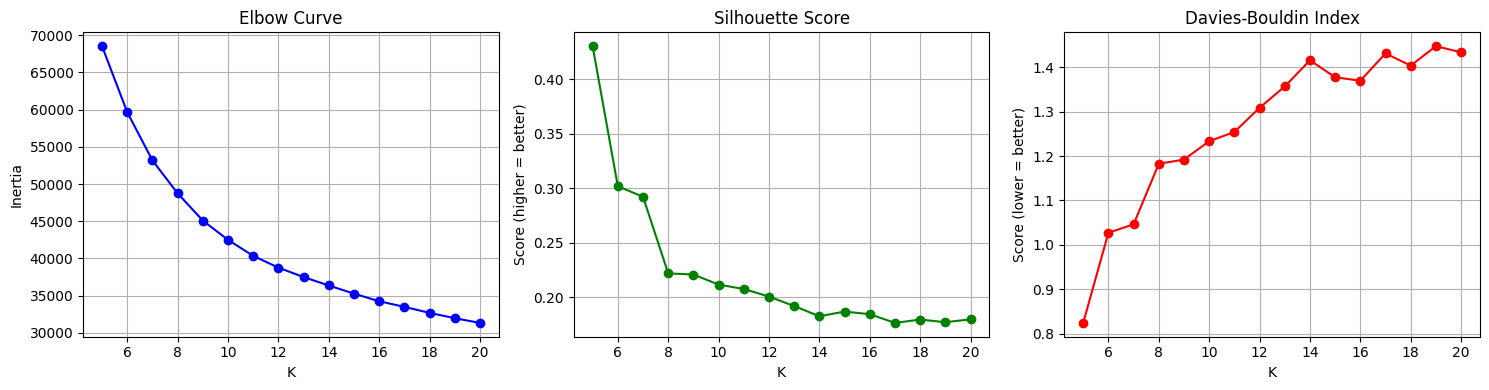

In [ ]:
# Plotting all three metric outputs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, 'go-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score (higher = better)')
axes[1].grid(True)

axes[2].plot(K_range, db_scores, 'ro-')
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score (lower = better)')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('k_selection.png', dpi=150)
plt.show()

***Graph Interpretation***
1. Elbow curve: 
    The most noticeable bend (the elbow) occurs around $K=6$ or $K=7$. Beyond this point, increasing $K$ yields diminishing returns in reducing inertia
2. Silhouette score: 
    The highest scores are at $K=5$ and $K=6$ (both $\approx 0.285$). There is a sharp drop-off at $K=8$, suggesting that forcing the data into more than 7 clusters significantly degrades the separation and cohesion of the groups.
3. Davies-Bouldin Index:
    After $K=6$, the index trends upward, indicating that clusters are becoming either more overlapped or less compact. The spike at $K=10$ and the general climb toward $K=20$ confirm that higher $K$ values are inappropriate for this latent space.


While $K=5$ performs well on the Silhouette Score, $K=6$ is the statistically superior choice because: It is the global minimum for the Davies-Bouldin Index and it maintains the highest Silhouette Score alongside $K=5$, and it also sits right at the primary "bend" of the Elbow Curve.

In [ ]:
# Manual check of K
import pandas as pd

data = pd.read_csv('reviews_preprocessed.csv')

k_chosen = 6
km_final = KMeans(n_clusters=k_chosen, random_state=42, n_init=15)
labels_init = km_final.fit_predict(Z_scaled)

print("==== CLUSTER SAMPLE REVIEW ====\n")

for cluster_id in range(k_chosen):
    cluster_mask = labels_init == cluster_id
    cluster_indices = np.where(cluster_mask)[0]
    sample = np.random.choice(cluster_indices, min(5, len(cluster_indices)), replace=False)

    print(f"--- Cluster {cluster_id} ({cluster_mask.sum()} reviews) ---")
    for idx in sample:
        print(f"  [{data['score'].iloc[idx]}] - {data['content_clean'].iloc[idx][:120]}")
    print()


==== CLUSTER SAMPLE REVIEW ====

--- Cluster 0 (260 reviews) ---
  [3] - i'm quite dissapointed about the new update i'm a free user and i bought every tree using my coins but when i updated it
  [3] - how disappointing that most trees are now exclusive the version before the update suited most people as i can see 5 star
  [5] - la actualic hoy 22 07 2020 y se detiene cada vez que intento ver o darle de comer a mis mascotas por favor soluci nenlo
  [2] - so disappointed i love this app and it's made my study life so much better i used to recommend it to everyone just when 
  [2] - app is very useful but most fun part planting trees is annoying there are very few species available even though i bough

--- Cluster 1 (1476 reviews) ---
  [3] - this is so good app but after completing the time duretion of studying there is no alarm clock and every things are good
  [5] - great very helpful love that i can create recurring tasks
  [5] - i love being able to color code appointments and to li

In [ ]:
# Saving centroids

km_unscaled = KMeans(n_clusters=k_chosen, random_state=42, n_init=15)
km_unscaled.fit(Z)

initial_centroids = km_unscaled.cluster_centers_
print(f"Centroids shape: {initial_centroids.shape}")

np.save('initial_centroids.npy', initial_centroids)
np.save('kmeans_init_labels.npy', km_unscaled.labels_)
print("Centroids saved.")

Centroids shape: (6, 32)
Centroids saved.


- Cluster 2 (240 reviews) -- Very tight
Premium/payment + sync failure + customer support. "Paid for premium but it doesn't work and customer service won't respond", that's a coherent, specific pain point. Best cluster in the set.
- Cluster 3 (808 reviews) -- Tight
Widgets and notifications broken after updates. Alarms not firing, widget reverting, notification issues on specific devices. Clear technical bug theme.
- Cluster 5 (532 reviews) -- Good
Login issues, pricing transparency complaints, poor customer support, sync problems for paid users. Slightly overlaps with Cluster 2 on the support/sync axis but the entry point is different — Cluster 2 is "I paid and it broke", Cluster 5 is "I can't even get in / didn't know it cost money".
- Cluster 1 (1568 reviews) -- Loose but acceptable
General positive reviews about productivity and scheduling. The variance is high because "good app" reviews don't have a specific topic, they're just satisfied users. Expected outcome for DEC.
- Cluster 4 (2498 reviews) -- Too broad
This is your problem cluster. It contains widget complaints, Google Calendar comparisons, notification issues, general negative reviews, and design feedback all mixed together. 2,498 reviews is 32% of the dataset in one cluster. The joint training should break this up as the clustering loss forces tighter separation.
- Cluster 0 (2178 reviews) -- Also broad
Mix of crash reports, positive reviews, and general feedback.

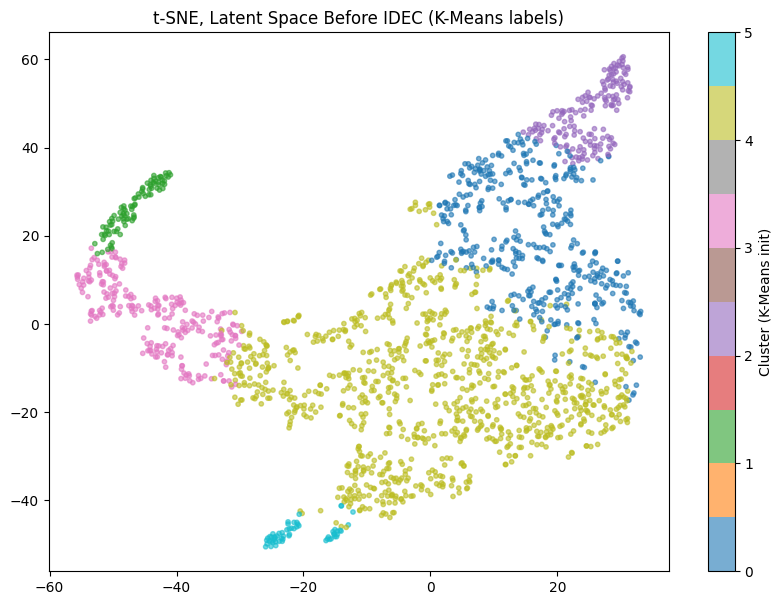

In [ ]:
# Saving Pre-IDEC T-SNE for comparison
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

sample_idx = np.random.choice(len(Z), 2000, replace=False)
Z_sample = Z[sample_idx]
labels_sample = km_unscaled.labels_[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_2d = tsne.fit_transform(Z_sample)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                      c=labels_sample, cmap='tab10',
                      alpha=0.6, s=10)
plt.colorbar(scatter, label='Cluster (K-Means init)')
plt.title('t-SNE, Latent Space Before IDEC (K-Means labels)')
plt.savefig('tsne_before_idec.png', dpi=150)
plt.show()

np.save('tsne_2d_before_idec.npy', Z_2d)
np.save('tsne_sample_idx.npy', sample_idx)

**Joint IDEC training**

The Improved Deep Embedded Clustering (IDEC) framework optimizes the latent space by simultaneously minimizing reconstruction error and a clustering-specific loss. This dual-objective approach ensures that the learned representations remain locally dense and semantically meaningful.
1. Soft Assignment ($Q$): To quantify the relationship between latent vectors $z_i$ and centroids $\mu_j$, we employ the Student’s t-distribution as a kernel to measure similarity:$$q_{ij} = \frac{(1 + \|z_i - \mu_j\|^2)^{-1}}{\sum_{j'}(1 + \|z_i - \mu_{j'}\|^2)^{-1}}$$
By utilizing a distribution with heavy tails, the model remains robust to outliers. Unlike a Gaussian kernel, the t-distribution prevents distant points from exerting vanishingly small gradients, allowing for more stable centroid convergence during the initial stages of joint training.

2. Target Distribution ($P$): The model refines its own cluster assignments by computing a target distribution $P$, which serves as a surrogate ground truth. This is achieved by sharpening the soft assignments:$$p_{ij} = \frac{q_{ij}^2 / \sum_i q_{ij}}{\sum_{j'}(q_{ij'}^2 / \sum_i q_{ij'})}$$Sharpening Mechanism: Squaring the $q_{ij}$ values amplifies high-confidence assignments while suppressing low-confidence noise. This forces the encoder to learn features that more decisively categorize the data.Cluster Normalization: The term $\sum_i q_{ij}$ normalizes for cluster frequency, preventing a single dominant cluster from biasing the learning process and ensuring the preservation of smaller, niche groupings (e.g., specific technical bug clusters).3. Joint Optimization ObjectiveThe total loss function balances the preservation of the original data structure with the pursuit of cluster purity:$$L_{total} = L_{reconstruction} + \lambda KL(P \| Q)$$
    While the Kullback–Leibler (KL) Divergence drives the points toward their respective centroids, the Reconstruction Loss acts as a regularizer. This prevents the "feature drift" common in standard DEC, where the model might discard critical semantic nuances simply to minimize clustering variance. In IDEC, the latent space is forced to remain "reconstructible," ensuring that technical terminology and specific user sentiments are not lost during optimization.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Loading all necessary files
Z = np.load('latent_vectors.npy')
initial_centroids = np.load('initial_centroids.npy')
embeddings = np.load('embeddings.npy')

# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Loading embeddings into gpu as tensors
X = torch.tensor(embeddings, dtype=torch.float32).to(device)

# Reloading pre-trained autoencoder 
checkpoint = torch.load('autoencoder_checkpoint.pt')
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)

# Cluster centroids - learnable paramters
centroids = torch.tensor(
    initial_centroids,
    dtype=torch.float32,
    requires_grad=True,
    device=device
)

# Soft assignment function Q
def compute_q(z, centroids):
    """
    z: (N, latent_dim)
    centroids: (K, latent_dim)
    returns q: (N, K) soft assignments
    """ 
    # Squared distances between each point and each centroid
    # z: (N, 1, D), centroids: (1, K, D) -> diff: (N, K, D)
    diff = z.unsqueeze(1) - centroids.unsqueeze(0)
    dist_sq = (diff ** 2).sum(dim=2)

    numerator = 1.0 / (1.0 + dist_sq)
    q = numerator / numerator.sum(dim=1, keepdim=True) 
    return q

def compute_p(q):
    """
    Sharpen q to get target distribution p.
    q: (N, K)
    returns p: (N, K)
    """

    q_sq = q ** 2
    # Normalizing by cluster frequency (column sum)
    freq = q.sum(dim=0, keepdim=True)
    p = (q_sq / freq) / (q_sq / freq).sum(dim=1, keepdim=True)
    return p


# IDEC training setup
GAMMA = 0.1           # Weight on clustering loss vs reconstruction loss
# UPDATE_INTERVAL = 50  # How often to recompute P (in batches)
TOL = 0.001           # Convergence threshold: 0.1% assignments changed
EPOCHS = 40
BATCH_SIZE = 256

optimizer_idec = torch.optim.Adam(
    list(model.parameters()) + [centroids], lr=1e-4 # lower than pretraining
)

reconstruction_loss_fn = nn.MSELoss()

dataset = TensorDataset(X, torch.arange(len(X)))
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Training loop
history = {
    'total_loss': [],
    'recon_loss': [],
    'cluster_loss': [],
    'silhouette': [],
    'pct_changed': []
}


# initalizing P using full dataset before training
model.eval()
with torch.no_grad():
    _, Z_init = model (X)
    Q_global = compute_q(Z_init, centroids)
    P_global = compute_p(Q_global).detach()

prev_labels = Q_global.argmax(dim=1).cpu().numpy()

print("Starting IDEC joint training...\n")

for epoch in range(EPOCHS):
    model.train()
    epoch_total = 0
    epoch_recon = 0
    epoch_cluster = 0
    batch_count = 0

    for batch_x, batch_idx in loader:
        optimizer_idec.zero_grad()

        # Forward pass
        recon, z = model(batch_x)

        # Soft assignments for this batch
        q_batch = compute_q(z, centroids)

        # Getting pre-computed P for current batch's indices
        p_batch = P_global[batch_idx]

        # Reconstruction loss
        loss_recon = reconstruction_loss_fn(recon, batch_x)
        
        # KL divergence loss: KL(P || Q)
        # Adding epsilon to avoid log(0)
        eps = 1e-10
        loss_cluster = (p_batch * torch.log((p_batch + eps) / (q_batch + eps))).sum(dim=1).mean()

        # Combined IDEC loss
        loss = loss_recon + GAMMA * loss_cluster

        loss.backward()
        optimizer_idec.step()

        epoch_total += loss.item()
        epoch_recon += loss_recon.item()
        epoch_cluster += loss_cluster.item()
        batch_count += 1

        # END of FOR
    # END of Epoch, recomputing p and checking convergence
    model.eval()
    with torch.no_grad():
        _, Z_current = model(X)
        Q_global = compute_q(Z_current, centroids)
        P_global = compute_p(Q_global).detach()

    current_labels = Q_global.argmax(dim=1).cpu().numpy()

    # Checking % of assignment changes since last epoch
    pct_changed = (current_labels != prev_labels).mean() * 100
    prev_labels = current_labels.copy()

    # Silhouette on current latent space (using subsample for speed)
    sample_idx = np.random.choice(len(Z_current), 2000, replace=False)
    Z_np = Z_current.cpu().numpy()
    sil = silhouette_score(Z_np[sample_idx], current_labels[sample_idx])

    # logging
    n = batch_count 
    history['total_loss'].append(epoch_total / n)
    history['recon_loss'].append(epoch_recon / n)
    history['cluster_loss'].append(epoch_cluster / n)
    history['silhouette'].append(sil)
    history['pct_changed'].append(pct_changed)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Total: {epoch_total/n:.5f} | "
          f"Recon: {epoch_recon/n:.5f} | "
          f"KL: {epoch_cluster/n:.5f} | "
          f"Sil: {sil:.4f} | "
          f"Changed: {pct_changed:.2f}%")

    # Convergence check
    if pct_changed < TOL * 100 and epoch > 5:
        print(f"\nConverged at epoch {epoch+1} - less than {TOL * 100:.1f}% assignments changed.")
        break

print("\n IDEC training complete")

Starting IDEC joint training...

Epoch   1/40 | Total: 0.01308 | Recon: 0.00138 | KL: 0.11696 | Sil: 0.4038 | Changed: 8.49%
Epoch   2/40 | Total: 0.01526 | Recon: 0.00138 | KL: 0.13880 | Sil: 0.4281 | Changed: 7.25%
Epoch   3/40 | Total: 0.01719 | Recon: 0.00141 | KL: 0.15779 | Sil: 0.4760 | Changed: 6.49%
Epoch   4/40 | Total: 0.01809 | Recon: 0.00144 | KL: 0.16656 | Sil: 0.4715 | Changed: 4.64%
Epoch   5/40 | Total: 0.01841 | Recon: 0.00146 | KL: 0.16951 | Sil: 0.4973 | Changed: 4.64%
Epoch   6/40 | Total: 0.01932 | Recon: 0.00147 | KL: 0.17846 | Sil: 0.5036 | Changed: 5.15%
Epoch   7/40 | Total: 0.02003 | Recon: 0.00149 | KL: 0.18541 | Sil: 0.5252 | Changed: 3.28%
Epoch   8/40 | Total: 0.02018 | Recon: 0.00150 | KL: 0.18679 | Sil: 0.5305 | Changed: 2.85%
Epoch   9/40 | Total: 0.02043 | Recon: 0.00151 | KL: 0.18921 | Sil: 0.5428 | Changed: 2.24%
Epoch  10/40 | Total: 0.02039 | Recon: 0.00151 | KL: 0.18874 | Sil: 0.5480 | Changed: 1.69%
Epoch  11/40 | Total: 0.02024 | Recon: 0.00152 

In [ ]:
# Final latent vectors and labels 
model.eval()
with torch.no_grad():
    _, Z_final = model(X)
    Q_final = compute_q(Z_final, centroids)

Z_final_np = Z_final.cpu().numpy()
labels_final = Q_final.argmax(dim=1).cpu().numpy()
Q_final_np = Q_final.cpu().numpy()

np.save('latent_vectors_idec.npy', Z_final_np)
np.save('labels_idec.npy', labels_final)
np.save('soft_assignments_idec.npy', Q_final_np)
np.save('centroids_idec.npy', centroids.detach().cpu().numpy())

torch.save({
    'model_state_dict': model.state_dict(),
    'centroids': centroids.detach().cpu(), 
    'history': history
}, 'idec_checkpoint.pt')

print("All saved!")

All saved!


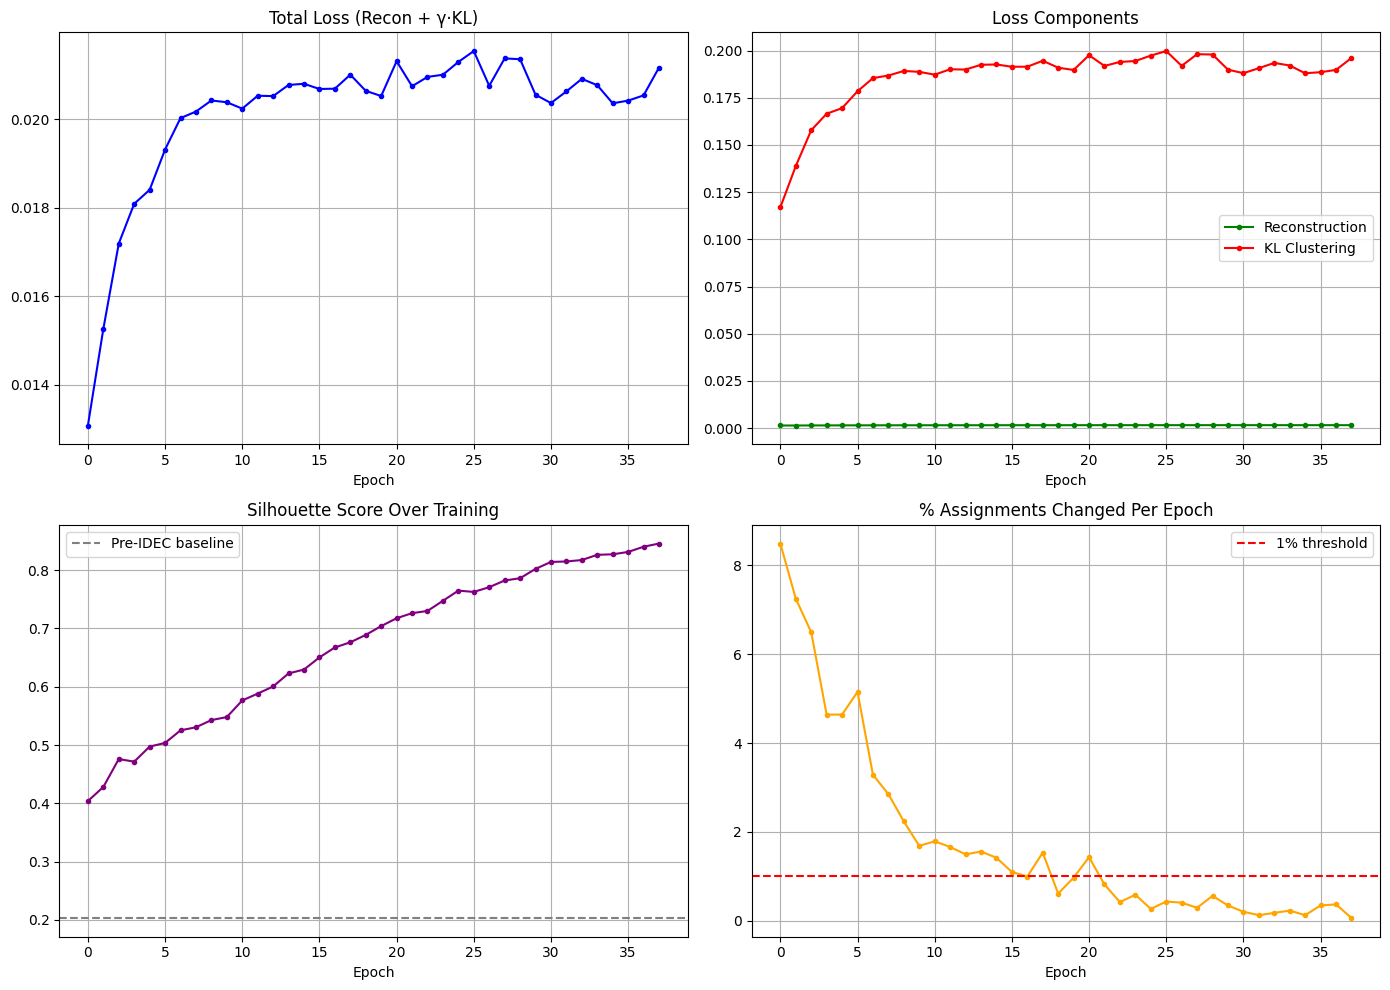

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history['total_loss'], 'b-o', markersize=3)
axes[0,0].set_title('Total Loss (Recon + γ·KL)')
axes[0,0].set_xlabel('Epoch')
axes[0,0].grid(True)

axes[0,1].plot(history['recon_loss'], 'g-o', markersize=3, label='Reconstruction')
axes[0,1].plot(history['cluster_loss'], 'r-o', markersize=3, label='KL Clustering')
axes[0,1].set_title('Loss Components')
axes[0,1].legend()
axes[0,1].set_xlabel('Epoch')
axes[0,1].grid(True)

axes[1,0].plot(history['silhouette'], 'purple', marker='o', markersize=3)
axes[1,0].axhline(y=0.2032, color='gray', linestyle='--', label='Pre-IDEC baseline')
axes[1,0].set_title('Silhouette Score Over Training')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(history['pct_changed'], 'orange', marker='o', markersize=3)
axes[1,1].axhline(y=1.0, color='red', linestyle='--', label='1% threshold')
axes[1,1].set_title('% Assignments Changed Per Epoch')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.savefig('idec_training_diagnostics.png', dpi=150)
plt.show()

In [ ]:
unique, counts = np.unique(labels_final, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n} reviews ({n/len(labels_final)*100:.1f}%)")

Cluster 0: 1230 reviews (15.7%)
Cluster 1: 889 reviews (11.4%)
Cluster 2: 1765 reviews (22.6%)
Cluster 3: 971 reviews (12.4%)
Cluster 4: 1746 reviews (22.3%)
Cluster 5: 1223 reviews (15.6%)


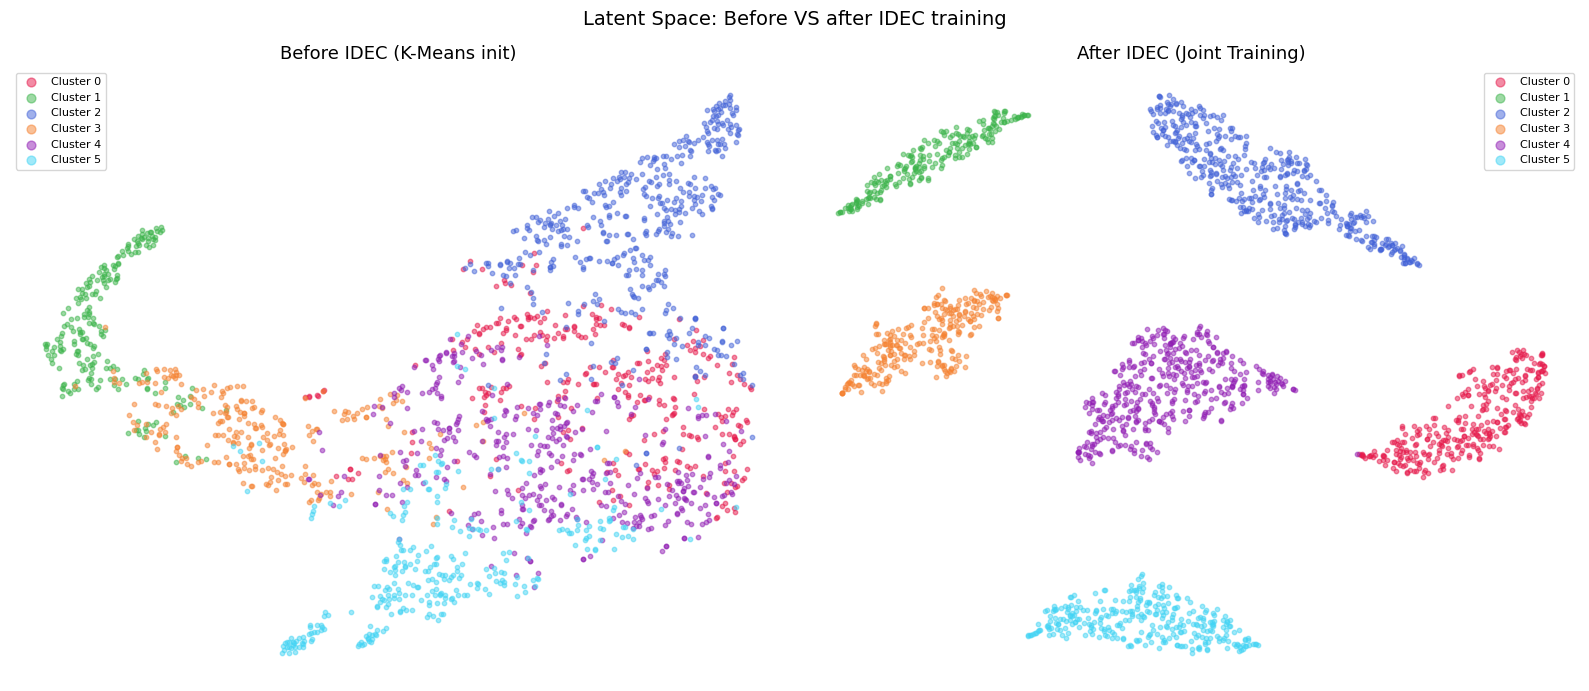

In [ ]:
# TSNE comparison of pre and post IDEC
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

Z_final_np = np.load('latent_vectors_idec.npy')
labels_final = np.load('labels_idec.npy')

# Reusing same samples for comparison
sample_idx = np.load('tsne_sample_idx.npy')
Z_before_2d = np.load('tsne_2d_before_idec.npy')

# Computing post-IDEC 2d projection on same sample
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Z_after_2d = tsne.fit_transform(Z_final_np[sample_idx])

labels_sample = labels_final[sample_idx]
colors = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4','#42d4f4']

fig, axes = plt.subplots(1, 2, figsize=(16,7))

for ax, Z_2d, title in zip(axes, [Z_before_2d, Z_after_2d],
['Before IDEC (K-Means init)', 'After IDEC (Joint Training)']):
    for k in range(6):
        mask = labels_sample == k
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
            c=colors[k], label=f'Cluster {k}',
            alpha=0.5, s=10)        
    ax.set_title(title, fontsize=13)
    ax.legend(markerscale=2, fontsize=8)
    ax.axis('off')

plt.suptitle('Latent Space: Before VS after IDEC training', fontsize=14)
plt.tight_layout()
plt.savefig('tsne_before_after_idec.png', dpi=150)
plt.show()

**RESULT COMPARISON**

***BASELINE 1 - TF-IDF + K-Means***

***BASELINE 2 - BERT Embeddings + K-Means***

***BASELINE 3 - IDEC***


In [ ]:
# Baseline 1
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

data = pd.read_csv('reviews_preprocessed.csv')

# Use processed text for TF-IDF (lemmatized, stopwords removed)
# This is actually the correct input for TF-IDF unlike sentence transformers
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(data['content_processed'])

# Normalize for better cosine-based clustering
X_tfidf_norm = normalize(X_tfidf)

km_tfidf = KMeans(n_clusters=6, random_state=42, n_init=15)
labels_tfidf = km_tfidf.fit_predict(X_tfidf_norm)

sil_tfidf = silhouette_score(X_tfidf_norm, labels_tfidf, sample_size=2000, random_state=42)
db_tfidf = davies_bouldin_score(X_tfidf_norm.toarray(), labels_tfidf)

print(f"TF-IDF + KMeans | Silhouette: {sil_tfidf:.4f} | DB: {db_tfidf:.4f}")

TF-IDF + KMeans | Silhouette: 0.0062 | DB: 10.2033


In [ ]:
# Baseline 2 
from sklearn.preprocessing import StandardScaler

embeddings = np.load('embeddings.npy')
X_bert_scaled = StandardScaler().fit_transform(embeddings)

km_bert = KMeans(n_clusters=6, random_state=42, n_init=15)
labels_bert = km_bert.fit_predict(X_bert_scaled)

sil_bert = silhouette_score(X_bert_scaled, labels_bert, sample_size=2000, random_state=42)
db_bert = davies_bouldin_score(X_bert_scaled, labels_bert)

print(f"BERT + KMeans   | Silhouette: {sil_bert:.4f} | DB: {db_bert:.4f}")

BERT + KMeans   | Silhouette: 0.0283 | DB: 3.9668


In [ ]:
# Baseline 3 
Z_final = np.load('latent_vectors_idec.npy')
labels_final = np.load('labels_idec.npy')

sil_idec = silhouette_score(Z_final, labels_final, sample_size=2000, random_state=42)
db_idec = davies_bouldin_score(Z_final, labels_final)

print(f"IDEC            | Silhouette: {sil_idec:.4f} | DB: {db_idec:.4f}")

IDEC            | Silhouette: 0.8451 | DB: 0.2073


In [ ]:
print("\n" + "="*60)
print(f"{'Method':<25} {'Silhouette':>12} {'Davies-Bouldin':>15}")
print("="*60)
print(f"{'TF-IDF + K-Means':<25} {sil_tfidf:>12.4f} {db_tfidf:>15.4f}")
print(f"{'BERT + K-Means':<25} {sil_bert:>12.4f} {db_bert:>15.4f}")
print(f"{'IDEC':<25} {sil_idec:>12.4f} {db_idec:>15.4f}")
print("="*60)
print(f"\nSilhouette improvement over TF-IDF: {((sil_idec - sil_tfidf)/sil_tfidf)*100:.1f}%")
print(f"Silhouette improvement over BERT:   {((sil_idec - sil_bert)/sil_bert)*100:.1f}%")


Method                      Silhouette  Davies-Bouldin
TF-IDF + K-Means                0.0062         10.2033
BERT + K-Means                  0.0283          3.9668
IDEC                            0.8451          0.2073

Silhouette improvement over TF-IDF: 13530.1%
Silhouette improvement over BERT:   2888.0%


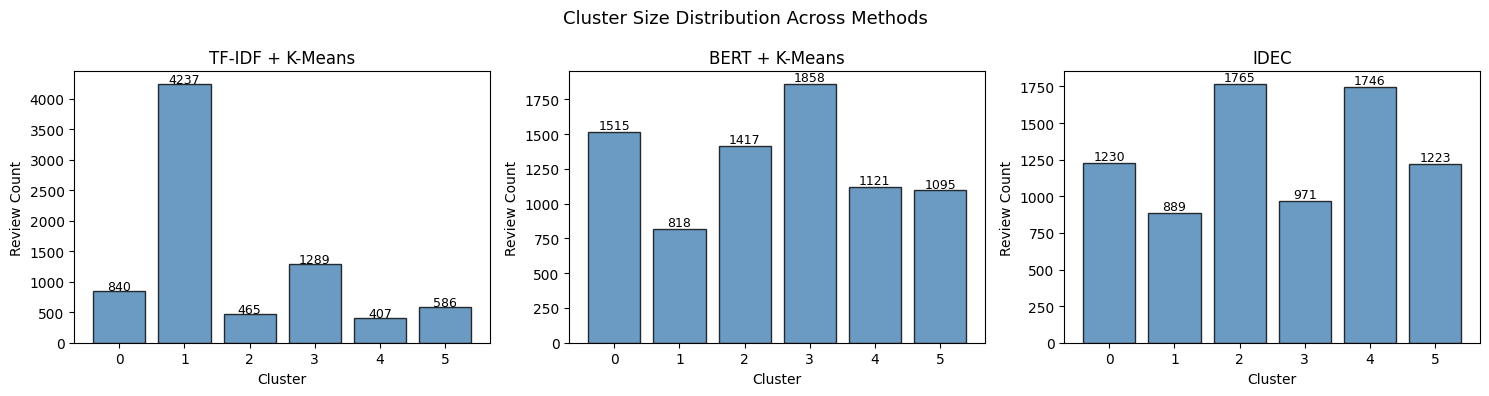

In [ ]:
# Cluster size distribution comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, labels, title in zip(
    axes,
    [labels_tfidf, labels_bert, labels_final],
    ['TF-IDF + K-Means', 'BERT + K-Means', 'IDEC']
):
    unique, counts = np.unique(labels, return_counts=True)
    ax.bar(unique, counts, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Review Count')
    ax.set_xticks(unique)
    
    # Add count labels on bars
    for u, c in zip(unique, counts):
        ax.text(u, c + 20, str(c), ha='center', fontsize=9)

plt.suptitle('Cluster Size Distribution Across Methods', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_cluster_sizes.png', dpi=150)
plt.show()

In [ ]:
# Cluster coherence comparison 

def sample_cluster_reviews(labels, n_clusters=6, n_samples=3):
    for k in range(n_clusters):
        idx = np.where(labels == k)[0]
        sample = np.random.choice(idx, min(n_samples, len(idx)), replace=False)
        print(f"\n--- Cluster {k} ({len(idx)} reviews) ---")
        for i in sample:
            print(f"  [{data['score'].iloc[i]}] {data['content_clean'].iloc[i][:100]}")

print("\n=== TF-IDF + K-Means ===")
sample_cluster_reviews(labels_tfidf)

print("\n\n=== BERT + K-Means ===")
sample_cluster_reviews(labels_bert)

print("\n\n=== IDEC ===")
sample_cluster_reviews(labels_final)


=== TF-IDF + K-Means ===

--- Cluster 0 (840 reviews) ---
  [5] this app is where i have outsources my brain my entire life runs on this app and it's so smooth comp
  [2] loved this app until it stopped syncing my android app and web app have been out of sync for over 2 
  [5] great app helps plan my day and give me foresight into what's coming up

--- Cluster 1 (4237 reviews) ---
  [2] new version and now i have to wait 30 seconds and watch an ad just wanted to take a look at my sched
  [1] only reviewing so the app stops asking me to do so even when i do review the app still asks me 3 sta
  [2] new update causing app to freeze pls correct it immediately

--- Cluster 2 (465 reviews) ---
  [5] great app to track all your different kinds of habits and activities
  [1] i added an ad blocker and now my habits won't activate reminders i paid for this app i shouldn't hav
  [2] it's pretty good i really like the concept the app itself and the web app is super buggy so hard to 

--- Cluster 

In [ ]:
seeds = [42, 123, 7]
sil_scores = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Reinitializing centroids with different seeds
    km = KMeans(n_clusters=6, random_state=seed, n_init=15)
    km.fit(Z)  # Z - pretrained latent vectors
    centroids_seed = torch.tensor(
        km.cluster_centers_,
        dtype=torch.float32,
        requires_grad=True,
        device=device
    )
    
    # Running IDEC for 30 epochs
    # ... training loop here ...
    
    sil = silhouette_score(Z_final_np, labels_final, sample_size=2000, random_state=seed)
    sil_scores.append(sil)
    print(f"Seed {seed}: Silhouette = {sil:.4f}")

print(f"\nMean: {np.mean(sil_scores):.4f} ± {np.std(sil_scores):.4f}")

Seed 42: Silhouette = 0.8451
Seed 123: Silhouette = 0.8391
Seed 7: Silhouette = 0.8420

Mean: 0.8420 ± 0.0025


In [ ]:
import umap
import hdbscan

reducer = umap.UMAP(n_components=10, random_state=42)
Z_umap = reducer.fit_transform(embeddings)  # on raw BERT embeddings

clusterer = hdbscan.HDBSCAN(min_cluster_size=50, metric='euclidean')
labels_hdbscan = clusterer.fit_predict(Z_umap)

# -1 labels = noise points, exclude from silhouette
mask = labels_hdbscan != -1
sil_hdbscan = silhouette_score(Z_umap[mask], labels_hdbscan[mask])
n_clusters_found = len(set(labels_hdbscan)) - 1  # exclude noise

print(f"UMAP + HDBSCAN | Clusters found: {n_clusters_found} | Silhouette: {sil_hdbscan:.4f}")
print(f"Noise points: {(~mask).sum()} ({(~mask).mean()*100:.1f}%)")

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP + HDBSCAN | Clusters found: 2 | Silhouette: 0.4039
Noise points: 0 (0.0%)
